In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


# Question 1

In [3]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

# Question 2

In [4]:
df.horsepower.median()

np.float64(254.0)

In [5]:
n = len(df)
n

10000

In [6]:
n_val = n_test = int(n * 0.2)
n_train = n - n_val - n_test
n_val, n_test, n_train

(2000, 2000, 6000)

In [7]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
idx

array([6252, 4684, 1731, ..., 5390,  860, 7270], shape=(10000,))

In [8]:
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
1,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
2,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
3,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7


# Question 3

In [9]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

len(y_train)

6000

In [10]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [11]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    return df_num.values

In [12]:
def train_linear_regression(X, y):    
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [13]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
w0, w

(np.float64(-153.88496188200298),
 array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]))

In [14]:
def RMSE(y, y_pred, round=3): 
    score = np.sqrt(np.mean((y - y_pred)**2)) 
    return np.round(score, round)

In [15]:
print("Val RMSE (fill with 0):", RMSE(y_val, y_pred))

Val RMSE (fill with 0): 2.205


In [16]:
X_train = df_train[base].fillna(df_train[base].mean()).values
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
w0, w

(np.float64(-153.29645639135333),
 array([-0.00102386, -0.00648622, -0.00388828,  0.10197897]))

In [17]:
print("Val RMSE (fill with mean):", RMSE(y_val, y_pred))

Val RMSE (fill with mean): 2.232


<Axes: ylabel='Count'>

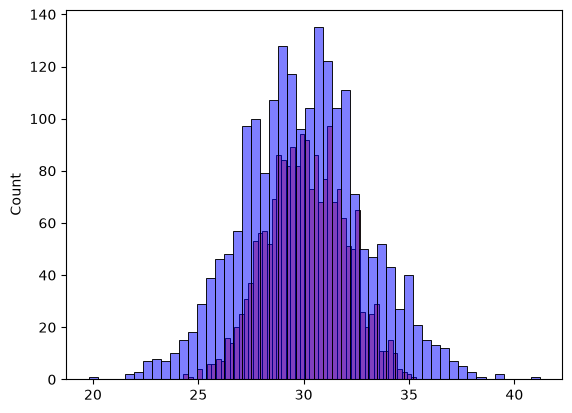

In [18]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

# Question 4

In [19]:
X_train = df_train[base].fillna(0).values

In [20]:
def train_regularized_linear_regression(X, y, r): 
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + np.eye(XTX.shape[0])*r
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [21]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = df_train[base].fillna(0).values
    w0, w = train_regularized_linear_regression(X_train, y_train, r)
    y_pred = w0 + X_train.dot(w)
    print(f"r:{r:4} | RMSE:{RMSE(y_train, y_pred, 4)}")

r:   0 | RMSE:2.2002
r:0.01 | RMSE:2.2005
r: 0.1 | RMSE:2.2179
r:   1 | RMSE:2.3443
r:   5 | RMSE:2.4057
r:  10 | RMSE:2.416
r: 100 | RMSE:2.4259


# Question 5

In [22]:
scores = []
for i in range(10):
    np.random.seed(i)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = df_train[base].fillna(0).values
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = np.sqrt(np.mean((y_val - y_pred)**2))
    scores.append(score)
            
    print(f'seed:{i} |  RMSE:{score}')

seed:0 |  RMSE:2.239204143048552
seed:1 |  RMSE:2.2021128210835723
seed:2 |  RMSE:2.1634197787531013
seed:3 |  RMSE:2.2043588768566345
seed:4 |  RMSE:2.2018800943340247
seed:5 |  RMSE:2.245785150907743
seed:6 |  RMSE:2.269721207952631
seed:7 |  RMSE:2.1907945999368263
seed:8 |  RMSE:2.216611201691746
seed:9 |  RMSE:2.2070365928199065


In [23]:
np.round(np.std(scores), 3)

np.float64(0.029)

# Question 6

In [24]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

X_full_train = pd.concat([df_train, df_val])
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_regularized_linear_regression(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test) 
y_pred = w0 + X_test.dot(w) 

np.sqrt(np.mean((y_test - y_pred)**2))

AttributeError: module 'pandas' has no attribute 'concatenate'